In [178]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [179]:
import json
from pprint import pprint

path = r'jobs\20251022_171601\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h512-256-128'
path = r'jobs\20251110_122808\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'
# path = r'jobs\20251111_165459\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'


metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


In [180]:
metrics_data['dataset_meta']

{'environment_config': {'num_modes': 25,
  'pixel_resolution': 64,
  'oversizing_factor': 1,
  'num_airy': 5,
  'coronagraph_charge': 6,
  'ppsr': 2},
 'dataset_config': {'N': 100000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'num_samples': 100000,
 'image_triplet_description': '(baseline, +nudge, -nudge)'}

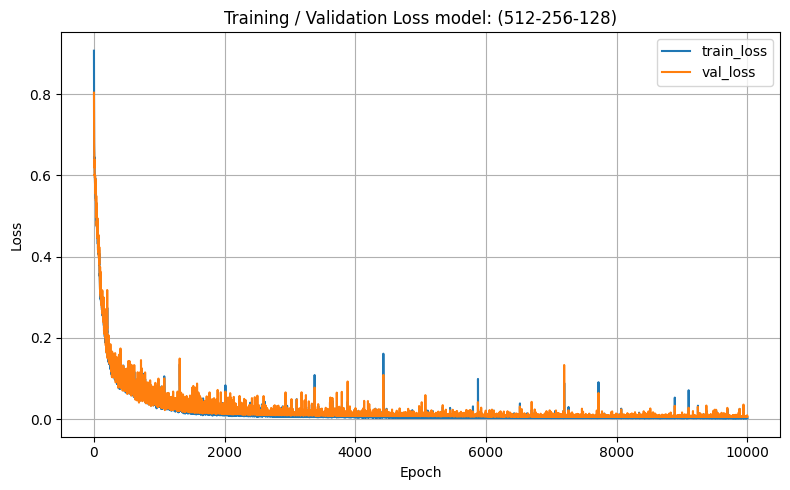

In [181]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training / Validation Loss model: (512-256-128)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [182]:
import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [183]:
metrics_data['y_norm']

{'mean': -2.08677190111084e-11, 'std': 1.9999989220309544e-08}

In [184]:
metrics_data.keys()

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])

In [185]:
metrics_data['dataset_meta']

{'environment_config': {'num_modes': 25,
  'pixel_resolution': 64,
  'oversizing_factor': 1,
  'num_airy': 5,
  'coronagraph_charge': 6,
  'ppsr': 2},
 'dataset_config': {'N': 100000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'num_samples': 100000,
 'image_triplet_description': '(baseline, +nudge, -nudge)'}

In [186]:
metrics_data['input_shape']

[20, 20, 3]

In [187]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=128, out_features=25, bias=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
)

In [313]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 782361


In [188]:
from environment import CoronagraphEnvironment

env_config = metrics_data['dataset_meta']['environment_config']
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')

env = CoronagraphEnvironment(**env_config, num_noise_modes=500)

initializing coronagraph env. might take a minute.


In [189]:
import pickle
from pathlib import Path

dataset_path = Path(r'data\dataset100K25M.pkl')
if not dataset_path.exists():
    raise FileNotFoundError(f"{dataset_path} not found")

with dataset_path.open('rb') as f:
    dataset = pickle.load(f)

print("Loaded:", dataset_path)
print("Type:", type(dataset))

if isinstance(dataset, dict):
    print("Keys:", list(dataset.keys()))
elif isinstance(dataset, (list, tuple)):
    print("Length:", len(dataset))
else:
    try:
        arr = np.asarray(dataset)  # np imported in another cell
        print("As numpy array shape:", arr.shape)
    except Exception:
        pass

# show a small preview without dumping everything
if isinstance(dataset, dict):
    for k in list(dataset.keys())[:10]:
        v = dataset[k]
        if isinstance(v, (list, tuple)):
            print(f"{k}: list len={len(v)}")
        else:
            print(f"{k}: type={type(v)}")
elif isinstance(dataset, (list, tuple)) and len(dataset):
    print("First element type:", type(dataset[0]))
    try:
        preview = dataset[0]
        if isinstance(preview, (list, tuple, dict, np.ndarray)):
            print("Preview (first element):", (preview if isinstance(preview, dict) else (np.asarray(preview).shape if hasattr(preview, '__len__') else type(preview))))
        else:
            print("Preview (first element):", preview)
    except Exception:
        pass

UnpicklingError: pickle data was truncated

In [190]:
pprint(dataset['meta'])
env_config

{'dataset_config': {'N': 10,
                    'delta_t': 0.001,
                    'dm_random_noise': 1e-07,
                    'noise_enabled': False,
                    'nudge_amplitude': 3e-07,
                    'nudge_mode_index': 0,
                    'save_checkpoints': None},
 'environment_config': {'basis': 'zernike',
                        'coronagraph_charge': 6,
                        'num_airy': 5,
                        'num_modes': 25,
                        'oversizing_factor': 1,
                        'pixel_resolution': 64,
                        'ppsr': 2},
 'image_triplet_description': '(baseline, +nudge, -nudge)',
 'nudge_vector': array([3.e-07, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00]),
 'num_samples': 10}


{'num_modes': 25,
 'oversizing_factor': 1,
 'num_airy': 5,
 'coronagraph_charge': 6,
 'pixels': 64,
 'pixels_per_spacial_res': 2}

In [191]:
new_imgs = dataset['images']

In [192]:
TEST_INDEX = 5

imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 10.345133120198568
tensor([[-4.4756e-08, -6.1378e-08,  2.2817e-08,  1.6277e-08,  2.9952e-09,
          1.2023e-08, -1.3633e-09,  1.4311e-08, -9.5853e-09, -2.3204e-08,
          6.5382e-09,  2.9422e-10,  1.4699e-09, -7.5369e-09, -1.3755e-08,
          2.3244e-08,  6.0701e-10, -1.9733e-09, -1.0937e-08, -9.3422e-10,
          2.8748e-09, -9.1449e-09,  6.9596e-10, -1.0762e-09, -1.7498e-09]])
[-7.73410390e-08 -1.95970484e-08  1.09609496e-07 -7.34360249e-08
 -5.18829871e-08  3.27317761e-09  1.47095427e-08  1.12195096e-07
 -3.28558195e-08 -4.47065601e-08  2.14462415e-08  1.64960276e-08
  1.12785107e-09 -1.54948774e-08  5.24787510e-08 -9.02248729e-09
 -1.07627666e-09 -1.78061626e-08  2.46451483e-08  4.89984895e-09
  4.71274592e-08  1.35853300e-08 -1.24852084e-08  7.96516342e-09
 -1.64521316e-08]


C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\350207380.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\350207380.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


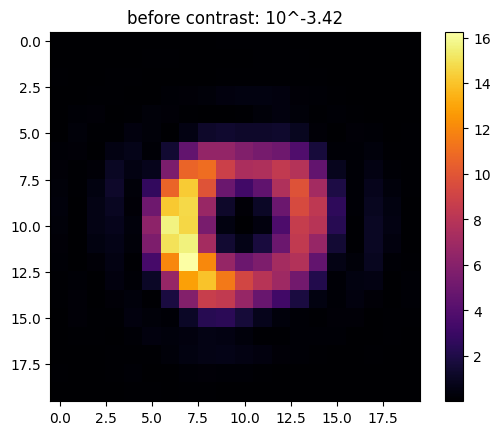

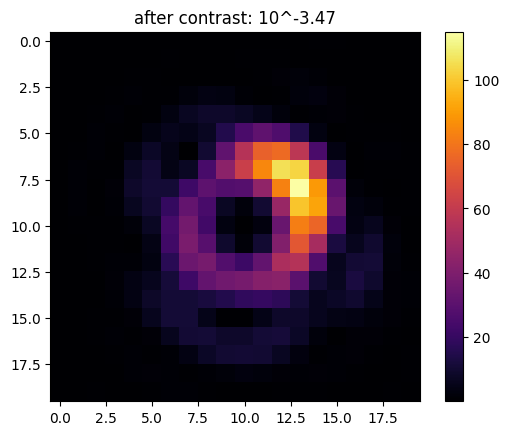

In [193]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

TEST_INDEX += 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        # env.deformable_mirror.flatten()
        # env.set_random_dm(noise=dm_random_noise)
        # original = env.deformable_mirror.actuators.copy()
        original = dataset['dm_settings'][TEST_INDEX]
        env.set_dm(action=original)

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = new_imgs[TEST_INDEX][0]


        img2 = new_imgs[TEST_INDEX][1]

        # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        img3 = new_imgs[TEST_INDEX][2]
        # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs, dtype=torch.float).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(img1, cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()



MSE: 1.3286330804111854


C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\3435297611.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\3435297611.py:55: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - 0.05 * np.array(y_pred[0])


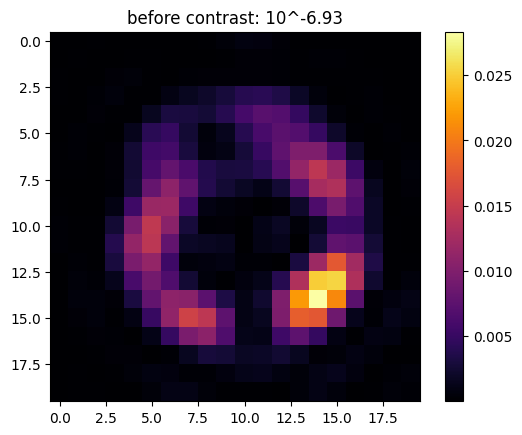

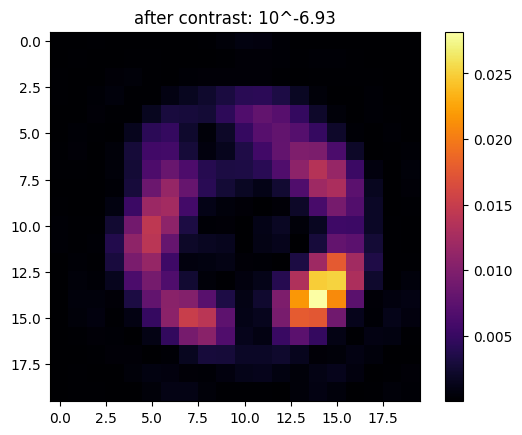

In [309]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        # env.deformable_mirror.flatten()
        # env.noise_gen_mirror.flatten()
        # env.set_random_dm(noise=dm_random_noise)
        env.set_nudge_vectors(vectors=[nudge_vec])
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)

        imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)
        
        # img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        # env.deformable_mirror.flatten()
        # env.deformable_mirror.actuators = original + nudge_vec
        # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        # env.deformable_mirror.flatten()
        # env.deformable_mirror.actuators = original - nudge_vec
        # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            # imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            # print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            # print(y_pred)
            # print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - 0.05 * np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(imgs[0][0], cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()

In [33]:
env.deformable_mirror.flatten()
env.noise_gen_mirror.flatten()
np.log10(env.get_contrast(delta_t=1e15))

np.float64(-8.195727883263018)

imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 6.7403274744586374
tensor([[-3.5958e-08, -4.0017e-10, -3.5572e-10, -9.8615e-08, -7.0402e-08,
         -1.0532e-09, -1.9837e-09, -1.1018e-08,  1.3428e-11,  7.9184e-09,
         -1.6236e-08, -2.6247e-10, -6.5241e-09,  2.2333e-08,  6.3162e-09,
          2.4457e-08, -9.1696e-10, -2.0502e-09, -5.8356e-09,  5.6102e-09,
          6.7313e-09,  9.3414e-12, -1.9530e-08,  5.5866e-09,  4.6666e-09]])
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


C:\Users\alexe\AppData\Local\Temp\ipykernel_1016\3645116021.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_1016\3645116021.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


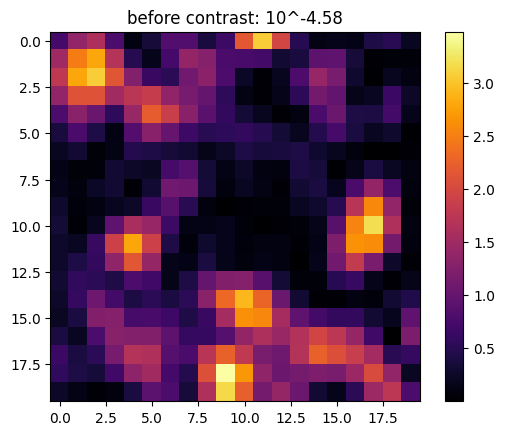

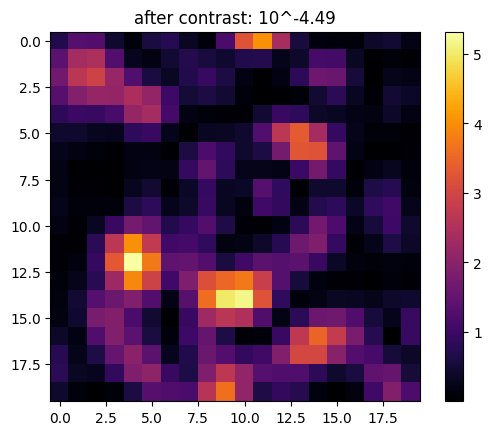

In [172]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        env.deformable_mirror.flatten()
        env.noise_gen_mirror.flatten()
        env.set_random_noise_dm(noise=1e-7)
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)
        env.set_nudge_vectors(vectors=[nudge_vec])
        img1g, img2g, img3g = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)

        img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()

